<a href="https://colab.research.google.com/github/Kryptera-K/BKNG-Adaptive-Keltner-Mean-Reversion-with-Volatility-Breakout-Strategy/blob/main/BKNG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "BKNG"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("BKNG_clean.csv", index=False)
df

/tmp/ipython-input-3063262458.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,302.549500,312.880458,283.363434,309.928756,847700
2000-01-04,318.783875,337.969941,302.549511,303.287436,972750
2000-01-05,353.835327,379.109279,322.473489,326.163117,1605417
2000-01-06,339.445740,378.555792,320.997602,362.321431,1175267
2000-01-07,337.969940,358.631858,328.376907,352.359490,339417
...,...,...,...,...,...
2025-12-19,5393.740234,5435.000000,5327.560059,5340.310059,462800
2025-12-22,5406.990234,5470.009766,5390.000000,5438.080078,135000
2025-12-23,5439.270020,5441.319824,5392.279785,5395.770020,120700


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

KC_MULTIPLIER = 2
KC_PERIOD = 20
STD_PERIOD = 14
STD_SHIFT = 5

# -------------------------
# Indicator Functions
# -------------------------

def kc_close_above_lower(df):
    df = calculate_keltner_channel(df)
    return df['Close'] > df['KC_Lower']


def calculate_keltner_channel(df, period=KC_PERIOD, multiplier=KC_MULTIPLIER):
    """
    Calculate Keltner Channel (Mid, Upper, Lower) and ATR.
    """
    df = df.copy()

    # Typical Price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3

    # EMA of Typical Price
    df['KC_Mid'] = df['TP'].ewm(span=period, adjust=False).mean()

    # True Range and ATR
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L','H-PC','L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(period).mean()

    # Upper and Lower Bands
    df['KC_Upper'] = df['KC_Mid'] + multiplier * df['ATR']
    df['KC_Lower'] = df['KC_Mid'] - multiplier * df['ATR']

    return df


def std_rising(df, shift=STD_SHIFT):
    df = calculate_std(df)
    return df['STD'] > df['STD'].shift(shift)


def calculate_std(df, period=STD_PERIOD):
    """Calculate rolling standard deviation and its change"""
    df['STD'] = df['Close'].rolling(period).std()
    df['STD_Change'] = df['STD'].diff()
    return df



# -------------------------
# Entry conditions
# -------------------------

df["KC_Close_Above_Lower"] = kc_close_above_lower(df)

# -------------------------
# Exit conditions
# -------------------------

df["STD_Rising"] = std_rising(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'KC_Close_Above_Lower',
]
exit_conditions = [
    'STD_Rising',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

Start                                2000-01-03 00:00:00
End                                  2025-12-26 00:00:00
Period                                6536 days 00:00:00
Start Value                                     100000.0
End Value                                 4172011.044415
Total Return [%]                             4072.011044
Benchmark Return [%]                         1654.041755
Max Gross Exposure [%]                             100.0
Total Fees Paid                             235932.07749
Max Drawdown [%]                               90.454641
Max Drawdown Duration                 2355 days 00:00:00
Total Trades                                          90
Total Closed Trades                                   89
Total Open Trades                                      1
Open Trade PnL                             398256.117727
Win Rate [%]                                   40.449438
Best Trade [%]                                358.124648
Worst Trade [%]                

In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2000-01-03 00:00:00
End                           2025-12-26 00:00:00
Period                         6536 days 00:00:00
Start Value                              100000.0
End Value                          1754041.755396
Total Return [%]                      1654.041755
Benchmark Return [%]                  1654.041755
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        98.870347
Max Drawdown Duration          3002 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                     1654041.755396
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


/tmp/ipython-input-2179429918.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


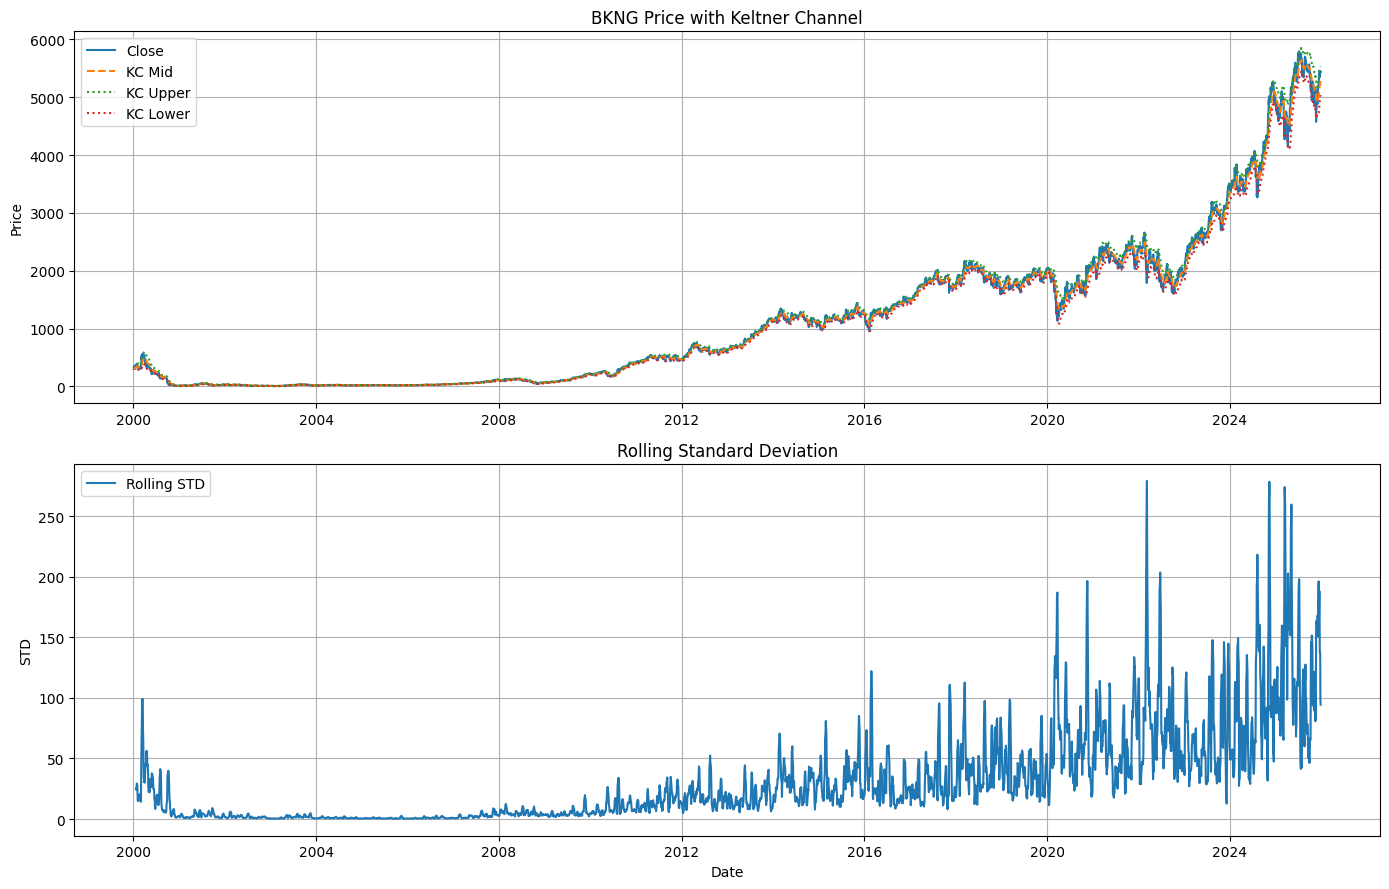

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------
# Download Data
# -------------------------
symbol = "BKNG"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(
    symbol,
    start=start_date,
    end=end_date,
    interval=interval,
    multi_level_index=False
)

# -------------------------
# Parameters
# -------------------------
KC_MULTIPLIER = 2
KC_PERIOD = 20
STD_PERIOD = 14
STD_SHIFT = 5

# -------------------------
# Indicator Functions
# -------------------------
def calculate_keltner_channel(df, period=KC_PERIOD, multiplier=KC_MULTIPLIER):
    df = df.copy()

    # Typical Price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3

    # EMA of TP
    df['KC_Mid'] = df['TP'].ewm(span=period, adjust=False).mean()

    # True Range
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = (df['High'] - df['Close'].shift(1)).abs()
    df['L-PC'] = (df['Low'] - df['Close'].shift(1)).abs()
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)

    # ATR
    df['ATR'] = df['TR'].rolling(period).mean()

    # KC Bands
    df['KC_Upper'] = df['KC_Mid'] + multiplier * df['ATR']
    df['KC_Lower'] = df['KC_Mid'] - multiplier * df['ATR']

    return df


def calculate_std(df, period=STD_PERIOD):
    df = df.copy()
    df['STD'] = df['Close'].rolling(period).std()
    df['STD_Change'] = df['STD'].diff()
    return df

# -------------------------
# Apply Indicators
# -------------------------
df = calculate_keltner_channel(df)
df = calculate_std(df)

# -------------------------
# Plotting
# -------------------------
plt.figure(figsize=(14, 9))

# --- Price + Keltner Channel ---
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df.index, df['Close'], label='Close')
ax1.plot(df.index, df['KC_Mid'], linestyle='--', label='KC Mid')
ax1.plot(df.index, df['KC_Upper'], linestyle=':', label='KC Upper')
ax1.plot(df.index, df['KC_Lower'], linestyle=':', label='KC Lower')

ax1.set_title(f"{symbol} Price with Keltner Channel")
ax1.set_ylabel("Price")
ax1.legend()
ax1.grid(True)

# --- Rolling STD ---
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(df.index, df['STD'], label='Rolling STD')
ax2.set_title("Rolling Standard Deviation")
ax2.set_ylabel("STD")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
